# Analisis Faktor-Faktor yang Mempengaruhi Kuat Tekan Beton Menggunakan Regresi Linier Berganda

## Deskripsi Dataset

Penelitian ini menggunakan dataset **Concrete Compressive Strength** yang diperoleh dari **UCI Machine Learning Repository** dan pertama kali dikumpulkan oleh **Prof. I-Cheng Yeh** dari Department of Information Management, Chung-Hua University, Taiwan.

Dataset ini merupakan dataset multivariat yang berisi data komposisi campuran beton dan hasil pengujian kuat tekan beton (*Concrete Compressive Strength*). Kuat tekan beton merupakan salah satu indikator utama kualitas beton dalam bidang teknik sipil dan dipengaruhi oleh berbagai komponen penyusun serta umur beton saat pengujian.

Dataset terdiri dari **1.030 observasi** dengan **9 variabel**, yang mencakup **8 variabel independen (input)** dan **1 variabel dependen (output)**. Seluruh data berada dalam bentuk asli (*raw data*) tanpa proses normalisasi atau standarisasi, serta **tidak memiliki nilai yang hilang (missing values)**.

## Tujuan Analisis

Analisis ini bertujuan untuk mengidentifikasi dan mengukur pengaruh komponen penyusun beton terhadap nilai kuat tekan beton (*Concrete Compressive Strength*) menggunakan metode **Analisis Korelasi Pearson** dan **Regresi Linier Berganda**.

Selain itu, penelitian ini bertujuan untuk membangun model regresi yang dapat digunakan untuk memprediksi kuat tekan beton berdasarkan komposisi material penyusunnya. Seluruh perhitungan dilakukan secara manual menggunakan operasi matriks tanpa memanfaatkan library statistik seperti *scikit-learn*, *scipy*, maupun *statsmodels*.

## Variabel Penelitian

### Variabel Dependen (Y)

**Concrete Compressive Strength (MPa)**

Variabel ini menunjukkan kuat tekan beton yang diperoleh melalui pengujian laboratorium dan menjadi variabel yang akan diprediksi dalam model regresi.

### Variabel Independen (X)

| Kode | Variabel           | Satuan |
| ---- | ------------------ | ------ |
| X1   | Cement             | kg/m³  |
| X2   | Blast Furnace Slag | kg/m³  |
| X3   | Fly Ash            | kg/m³  |
| X4   | Water              | kg/m³  |
| X5   | Superplasticizer   | kg/m³  |
| X6   | Coarse Aggregate   | kg/m³  |
| X7   | Fine Aggregate     | kg/m³  |
| X8   | Age                | hari   |

Keterangan:

* **Cement**: jumlah semen dalam campuran beton.
* **Blast Furnace Slag**: jumlah slag tanur tinggi yang digunakan sebagai bahan tambahan beton.
* **Fly Ash**: jumlah abu terbang yang digunakan dalam campuran beton.
* **Water**: jumlah air dalam campuran beton.
* **Superplasticizer**: bahan tambahan kimia yang berfungsi meningkatkan workability beton.
* **Coarse Aggregate**: agregat kasar seperti kerikil yang digunakan dalam campuran beton.
* **Fine Aggregate**: agregat halus seperti pasir yang digunakan dalam campuran beton.
* **Age**: umur beton saat dilakukan pengujian kuat tekan (1–365 hari).

## Metode Analisis

Tahapan analisis yang dilakukan dalam penelitian ini meliputi:

1. Eksplorasi data (*Exploratory Data Analysis/EDA*).
2. Analisis statistik deskriptif untuk memahami karakteristik data.
3. Visualisasi distribusi data menggunakan histogram dan boxplot.
4. Visualisasi hubungan antar variabel menggunakan scatter plot.
5. Analisis Korelasi Pearson untuk mengukur kekuatan hubungan antar variabel.
6. Pemodelan Regresi Linier Berganda menggunakan metode Ordinary Least Squares (OLS) berbasis operasi matriks.
7. Evaluasi model menggunakan koefisien determinasi (R²).
8. Pengujian signifikansi model menggunakan Uji F dan Uji t.
9. Prediksi nilai kuat tekan beton berdasarkan nilai variabel independen tertentu.
10. Interpretasi hasil analisis dan penarikan kesimpulan.

## Sumber Dataset

Yeh, I.-C. (2007). *Concrete Compressive Strength Dataset*. UCI Machine Learning Repository.

Dataset tersedia pada:
https://archive.ics.uci.edu/ml/datasets/concrete+compressive+strength


## 1. Import Library dan Load Dataset

Pada tahap awal dilakukan import library yang diperlukan serta pengambilan dataset yang akan digunakan dalam analisis.

Dataset yang digunakan adalah **Concrete Compressive Strength** yang diperoleh langsung dari **UCI Machine Learning Repository** menggunakan package `ucimlrepo`. Dengan cara ini dataset dapat diakses secara otomatis tanpa perlu mengunggah file secara manual ke Google Colab.

Library yang digunakan pada penelitian ini terdiri dari:

- **pandas**, untuk mengelola data dalam bentuk DataFrame.
- **numpy**, untuk operasi numerik dan perhitungan matriks.
- **matplotlib**, untuk visualisasi data.
- **ucimlrepo**, untuk mengambil dataset dari UCI Machine Learning Repository.

Sesuai ketentuan tugas, seluruh perhitungan statistik seperti korelasi Pearson, regresi linier berganda, koefisien determinasi (R²), uji F, dan uji t dilakukan secara manual tanpa menggunakan library statistik maupun machine learning seperti `sklearn`, `scipy`, atau `statsmodels`.

In [ ]:
pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

# Mengambil dataset Concrete Compressive Strength dari UCI Repository
concrete_compressive_strength = fetch_ucirepo(id=165)

# Data fitur (X) dan target (Y)
X = concrete_compressive_strength.data.features
y = concrete_compressive_strength.data.targets

# Menggabungkan menjadi satu DataFrame
df = pd.concat([X, y], axis=1)

# Mengubah nama kolom agar lebih ringkas dan mudah dibaca
df.columns = [
    "Cement",
    "Blast_Furnace_Slag",
    "Fly_Ash",
    "Water",
    "Superplasticizer",
    "Coarse_Aggregate",
    "Fine_Aggregate",
    "Age",
    "Concrete_Compressive_Strength"
]

df.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_Compressive_Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 2. Eksplorasi Data (EDA)

Exploratory Data Analysis (EDA) merupakan tahapan awal yang penting dalam proses analisis data untuk memahami karakteristik dataset sebelum dilakukan analisis statistik maupun pemodelan yang lebih kompleks. EDA bertujuan untuk mengidentifikasi pola, tren, hubungan antar variabel, serta mendeteksi anomali atau permasalahan data yang dapat memengaruhi hasil analisis. :contentReference[oaicite:0]{index=0}

Menurut Maresti et al. (2024), EDA digunakan untuk menginvestigasi data melalui rangkuman statistik dan visualisasi guna menemukan pola, mengevaluasi hipotesis, serta memverifikasi asumsi yang berkaitan dengan data. Selain itu, EDA membantu memastikan kualitas data sebelum dilakukan analisis lanjutan. :contentReference[oaicite:1]{index=1}

Pada penelitian ini, tahap EDA meliputi:
- Pemeriksaan ukuran dan struktur dataset.
- Pemeriksaan tipe data setiap variabel.
- Pemeriksaan missing value.
- Analisis statistik deskriptif.
- Analisis distribusi data menggunakan histogram.
- Analisis hubungan antar variabel menggunakan korelasi dan visualisasi.
- Identifikasi outlier menggunakan boxplot.

Tahap EDA dilakukan untuk memperoleh pemahaman awal terhadap data Concrete Compressive Strength sehingga proses analisis korelasi dan regresi linier berganda dapat dilakukan secara lebih akurat.

### 2.1 Data Understanding

Tahap Data Understanding dilakukan untuk memahami struktur dataset yang digunakan, meliputi jumlah observasi, jumlah variabel, serta tipe data setiap variabel. Tahap ini penting untuk memastikan data telah sesuai dan siap digunakan pada proses analisis berikutnya. Menurut Maresti et al. (2024), Data Understanding merupakan tahapan awal EDA yang bertujuan memahami karakteristik data setelah data berhasil dikumpulkan. :contentReference[oaicite:0]{index=0}

In [ ]:
print("Ukuran data (baris, kolom):", df.shape)

pd.DataFrame({
    "Variabel": df.columns,
    "Tipe Data": df.dtypes.values
})

Ukuran data (baris, kolom): (1030, 9)


,Variabel,Tipe Data
0,Cement,float64
1,Blast_Furnace_Slag,float64
2,Fly_Ash,float64
3,Water,float64
4,Superplasticizer,float64
5,Coarse_Aggregate,float64
6,Fine_Aggregate,float64
7,Age,int64
8,Concrete_Compressive_Strength,float64


### 2.2 Data Preprocessing

Tahap Data Preprocessing dilakukan untuk memeriksa kualitas data sebelum dilakukan analisis lebih lanjut. Salah satu langkah penting pada tahap ini adalah pemeriksaan *missing value* untuk memastikan tidak terdapat data yang hilang yang dapat memengaruhi hasil analisis.

In [ ]:
missing_value = pd.DataFrame({
    "Variabel": df.columns,
    "Jumlah Missing Value": df.isnull().sum().values
})

missing_value

,Variabel,Jumlah Missing Value
0,Cement,0
1,Blast_Furnace_Slag,0
2,Fly_Ash,0
3,Water,0
4,Superplasticizer,0
5,Coarse_Aggregate,0
6,Fine_Aggregate,0
7,Age,0
8,Concrete_Compressive_Strength,0


Berdasarkan hasil pemeriksaan *missing value*, seluruh variabel memiliki nilai 0 sehingga tidak ditemukan data yang hilang (*missing value*) pada dataset. Dengan demikian, tidak diperlukan proses imputasi maupun penghapusan data dan seluruh observasi dapat digunakan pada tahap analisis berikutnya.

### 2.3 Analisis Statistik Deskriptif

Analisis statistik deskriptif dilakukan untuk memberikan gambaran umum mengenai karakteristik setiap variabel dalam dataset. Statistik yang ditampilkan meliputi jumlah data (*count*), nilai rata-rata (*mean*), standar deviasi (*standard deviation*), nilai minimum (*minimum*), kuartil pertama (Q1), median (Q2), kuartil ketiga (Q3), dan nilai maksimum (*maximum*).

In [ ]:
statistik_deskriptif = df.describe().T
statistik_deskriptif

,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
Blast_Furnace_Slag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
Fly_Ash,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
Water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
Superplasticizer,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
Coarse_Aggregate,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
Fine_Aggregate,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
Age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
Concrete_Compressive_Strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6


Berdasarkan hasil statistik deskriptif, seluruh variabel memiliki jumlah observasi sebanyak **1.030 data**, yang menunjukkan tidak adanya data yang hilang pada dataset.

Variabel dependen **Concrete Compressive Strength** memiliki rata-rata sebesar **35,82 MPa** dengan nilai minimum **2,33 MPa** dan maksimum **82,60 MPa**. Nilai standar deviasi sebesar **16,71** menunjukkan adanya variasi kekuatan tekan beton yang cukup beragam pada dataset.

Untuk variabel independen, **Cement** memiliki rata-rata sebesar **281,17 kg/m³** dengan rentang nilai antara **102 kg/m³** hingga **540 kg/m³**. Variabel **Water** memiliki rata-rata sebesar **181,57 kg/m³**, sedangkan **Age** memiliki rata-rata **45,66 hari** dengan rentang yang sangat lebar, yaitu dari **1 hari** hingga **365 hari**.

Nilai standar deviasi yang relatif besar pada variabel **Blast Furnace Slag** (86,28), **Fly Ash** (64,00), dan **Age** (63,17) menunjukkan bahwa data pada variabel tersebut memiliki tingkat variasi yang cukup tinggi. Sementara itu, variabel **Superplasticizer** memiliki rata-rata sebesar **6,20 kg/m³** dengan nilai minimum **0** dan maksimum **32,2 kg/m³**, yang menunjukkan bahwa tidak semua campuran beton menggunakan bahan tambahan tersebut.

Secara umum, statistik deskriptif menunjukkan bahwa dataset memiliki variasi data yang cukup beragam pada setiap variabel, sehingga layak digunakan untuk analisis korelasi Pearson dan pemodelan regresi linier berganda.


### 2.4 Analisis Distribusi Data

Visualisasi distribusi data dilakukan menggunakan histogram untuk melihat pola persebaran setiap variabel. Histogram membantu mengidentifikasi bentuk distribusi data, tingkat penyebaran data, serta kemungkinan adanya kemencengan distribusi (*skewness*) pada masing-masing variabel.

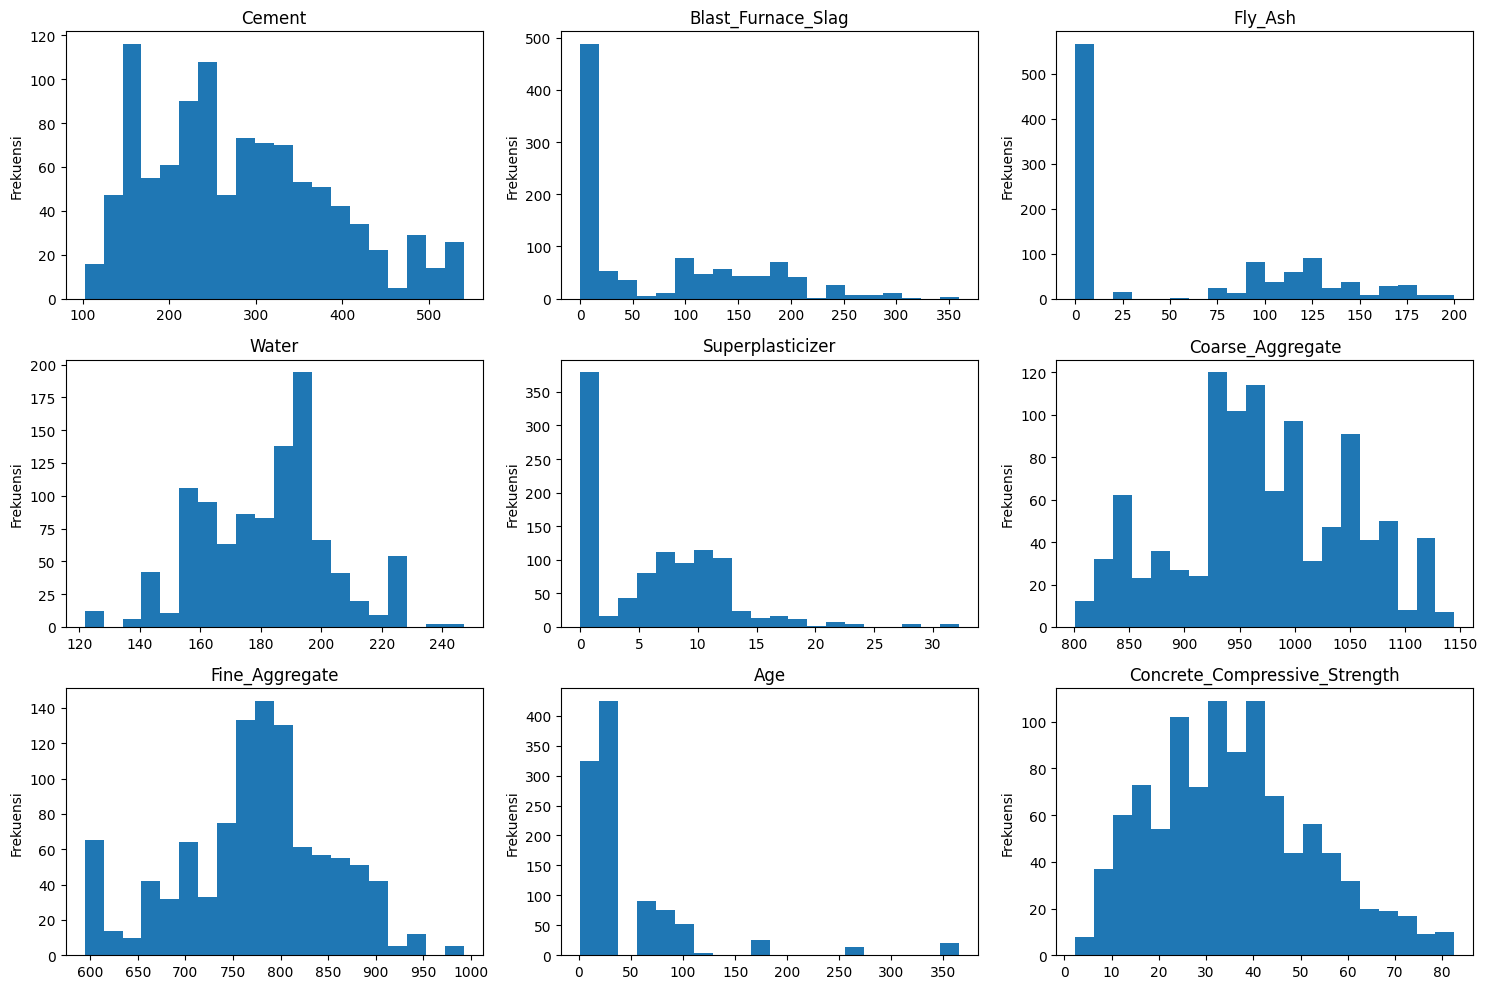

In [ ]:
plt.figure(figsize=(15,10))

for i, kolom in enumerate(df.columns):
    plt.subplot(3,3,i+1)

    plt.hist(df[kolom], bins=20)

    plt.title(kolom)
    plt.xlabel("")
    plt.ylabel("Frekuensi")

plt.tight_layout()
plt.show()

### Interpretasi Histogram

Berdasarkan histogram yang dihasilkan, terlihat bahwa distribusi data pada setiap variabel memiliki karakteristik yang berbeda-beda.

Variabel **Cement**, **Water**, **Coarse Aggregate**, **Fine Aggregate**, dan **Concrete Compressive Strength** menunjukkan distribusi yang relatif menyebar pada berbagai rentang nilai. Variabel **Concrete Compressive Strength** memiliki pola distribusi yang mendekati distribusi normal dengan konsentrasi data pada rentang sekitar 20–50 MPa.

Variabel **Blast Furnace Slag**, **Fly Ash**, dan **Superplasticizer** menunjukkan distribusi yang sangat tidak simetris (right-skewed), ditandai dengan banyaknya observasi pada nilai 0 atau mendekati 0. Hal ini mengindikasikan bahwa tidak semua campuran beton menggunakan bahan tambahan tersebut.

Variabel **Age** juga menunjukkan distribusi yang tidak merata dengan konsentrasi data yang tinggi pada umur beton tertentu, terutama pada rentang 1–28 hari. Kondisi ini menunjukkan bahwa sebagian besar pengujian kuat tekan dilakukan pada umur beton yang relatif muda.

Secara keseluruhan, histogram menunjukkan bahwa beberapa variabel tidak mengikuti distribusi normal secara sempurna. Namun demikian, variasi data yang cukup besar pada setiap variabel memberikan informasi yang memadai untuk dilakukan analisis korelasi Pearson dan pemodelan regresi linier berganda.

### 2.5 Analisis Korelasi Antar Variabel

Matriks korelasi digunakan untuk melihat kekuatan dan arah hubungan antar variabel dalam dataset. Nilai koefisien korelasi berada pada rentang -1 hingga 1, di mana nilai positif menunjukkan hubungan searah, sedangkan nilai negatif menunjukkan hubungan berlawanan arah.

Visualisasi matriks korelasi membantu mengidentifikasi variabel yang memiliki hubungan kuat terhadap variabel dependen maupun potensi hubungan antar variabel independen yang dapat menyebabkan multikolinearitas.

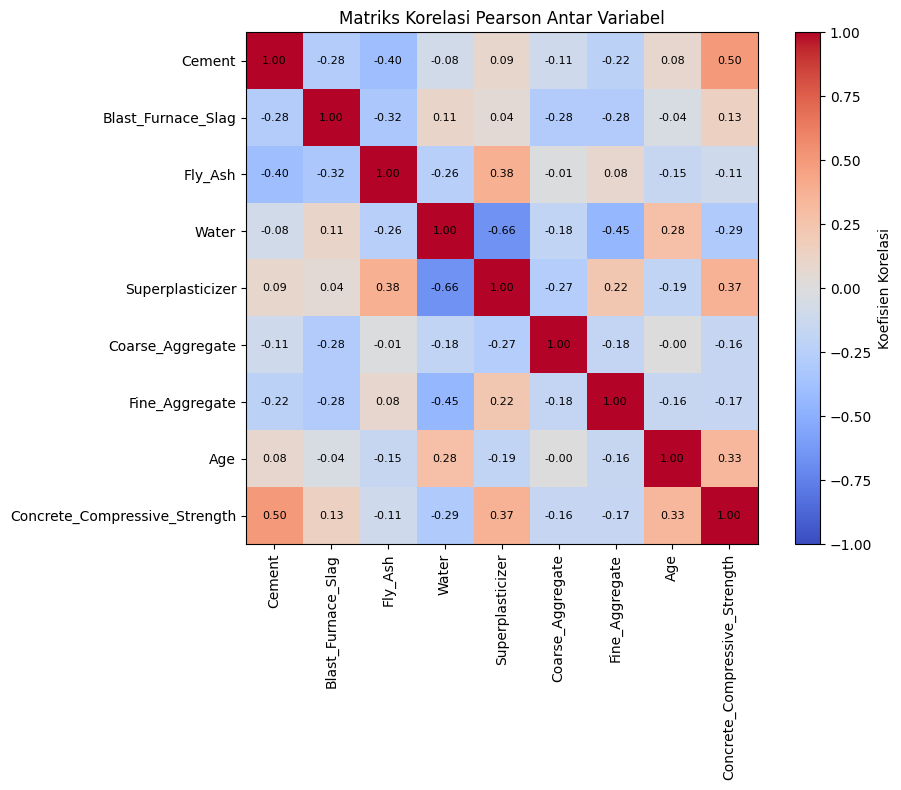

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(10,8))

plt.imshow(
    corr_matrix,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.colorbar(label='Koefisien Korelasi')

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

# Menampilkan nilai korelasi pada setiap sel
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            fontsize=8,
            color='black'
        )

plt.title("Matriks Korelasi Pearson Antar Variabel")

plt.tight_layout()
plt.show()

### 2.6 Identifikasi Outlier

Boxplot digunakan untuk mengidentifikasi keberadaan nilai ekstrem (*outlier*) pada setiap variabel dalam dataset. Outlier merupakan observasi yang berada jauh di luar sebaran mayoritas data dan berpotensi memengaruhi hasil analisis statistik maupun pemodelan regresi.

Melalui boxplot, dapat diamati nilai minimum, kuartil pertama (Q1), median (Q2), kuartil ketiga (Q3), serta observasi yang berada di luar batas whisker. Identifikasi outlier dilakukan sebagai bagian dari proses Exploratory Data Analysis (EDA) untuk memahami karakteristik data sebelum dilakukan analisis lanjutan.

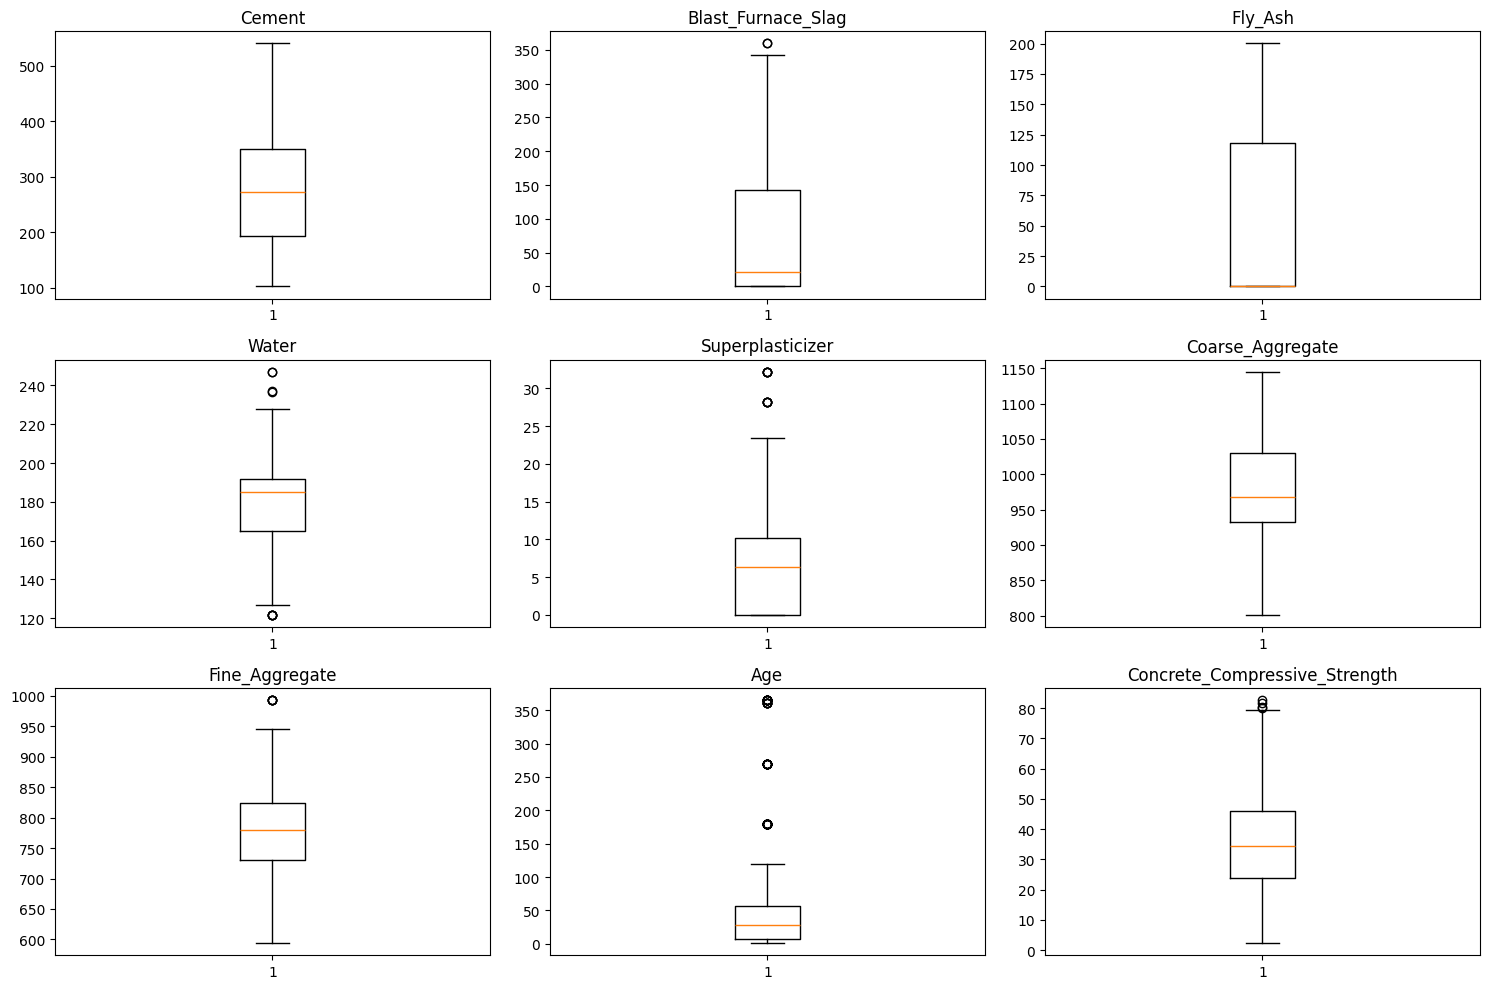

In [ ]:
plt.figure(figsize=(15,10))

for i, kolom in enumerate(df.columns):

    plt.subplot(3,3,i+1)

    plt.boxplot(df[kolom])

    plt.title(kolom)

plt.tight_layout()
plt.show()

### Interpretasi Boxplot

Berdasarkan boxplot yang dihasilkan, sebagian besar variabel memiliki sebaran data yang cukup luas dengan beberapa nilai yang berada di luar rentang utama data (*outlier*).

Variabel **Age** menunjukkan jumlah outlier yang paling banyak, terutama pada umur beton yang relatif tinggi seperti 180, 270, dan 365 hari. Hal ini menunjukkan bahwa sebagian kecil sampel beton diuji pada umur yang jauh lebih lama dibandingkan mayoritas data.

Variabel **Water** juga memiliki beberapa outlier pada nilai yang sangat rendah maupun sangat tinggi dibandingkan mayoritas observasi. Selain itu, variabel **Superplasticizer**, **Blast Furnace Slag**, **Fine Aggregate**, dan **Concrete Compressive Strength** menunjukkan keberadaan beberapa outlier pada bagian atas distribusi data.

Sementara itu, variabel **Cement** dan **Coarse Aggregate** tidak menunjukkan outlier yang signifikan sehingga distribusi datanya relatif lebih stabil dibandingkan variabel lainnya.

Keberadaan outlier pada dataset ini masih dianggap wajar karena data berasal dari berbagai komposisi campuran beton dan kondisi pengujian yang berbeda. Oleh karena itu, seluruh observasi tetap dipertahankan dalam analisis agar informasi yang terkandung dalam dataset tidak hilang dan model dapat merepresentasikan kondisi data yang sebenarnya.

## 3. Visualisasi Hubungan Antarvariabel (Scatter Plot)

Scatter plot digunakan untuk melihat pola hubungan antara masing-masing variabel independen dengan variabel dependen, yaitu **Concrete Compressive Strength**. Melalui visualisasi ini dapat diamati apakah hubungan yang terbentuk cenderung positif, negatif, linier, atau tidak menunjukkan pola tertentu.

Visualisasi scatter plot juga membantu memberikan gambaran awal mengenai kekuatan hubungan antar variabel sebelum dilakukan analisis korelasi Pearson dan pemodelan regresi linier berganda.

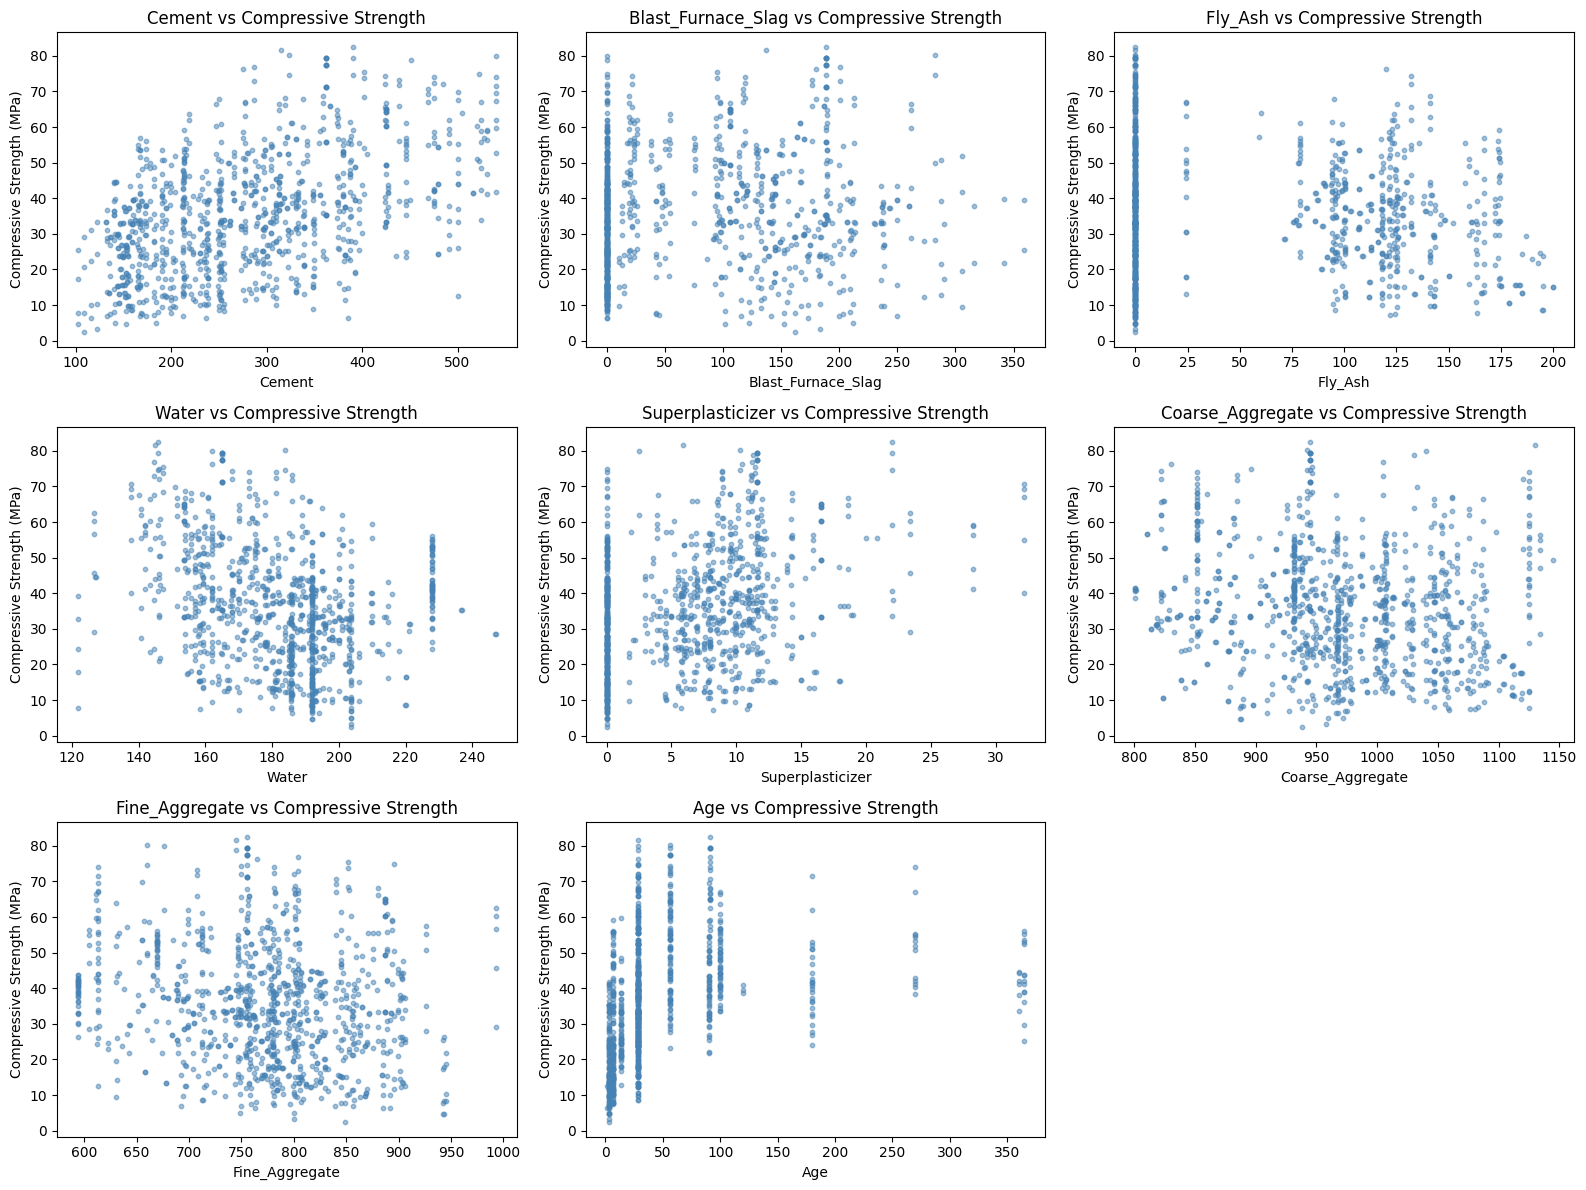

In [ ]:
fitur_X = ["Cement", "Blast_Furnace_Slag", "Fly_Ash", "Water",
           "Superplasticizer", "Coarse_Aggregate", "Fine_Aggregate", "Age"]

target = df["Concrete_Compressive_Strength"]

plt.figure(figsize=(16, 12))

for i, kolom in enumerate(fitur_X):
    plt.subplot(3, 3, i + 1)

    plt.scatter(
        df[kolom],
        target,
        alpha=0.5,
        s=10,
        color="steelblue"
    )

    plt.xlabel(kolom)
    plt.ylabel("Compressive Strength (MPa)")
    plt.title(f"{kolom} vs Compressive Strength")

plt.tight_layout()
plt.show()

### Interpretasi Scatter Plot

Berdasarkan scatter plot yang dihasilkan, terlihat bahwa beberapa variabel memiliki kecenderungan hubungan dengan kuat tekan beton.

Variabel Cement, Superplasticizer, dan Age menunjukkan kecenderungan hubungan positif, di mana peningkatan nilai variabel tersebut cenderung diikuti oleh peningkatan kuat tekan beton. Sebaliknya, variabel Water menunjukkan kecenderungan hubungan negatif, yang mengindikasikan bahwa peningkatan jumlah air dalam campuran beton cenderung menurunkan kuat tekan beton.

Sementara itu, variabel Blast Furnace Slag, Fly Ash, Coarse Aggregate, dan Fine Aggregate tidak menunjukkan pola hubungan yang terlalu jelas secara visual. Oleh karena itu, diperlukan analisis korelasi Pearson untuk mengukur kekuatan hubungan antar variabel secara kuantitatif.

## 4. Analisis Korelasi Pearson

Analisis korelasi Pearson digunakan untuk mengukur kekuatan dan arah hubungan linear antara variabel independen dengan variabel dependen (*Concrete Compressive Strength*).

Koefisien korelasi Pearson dinotasikan dengan **r** dan memiliki nilai antara **-1 hingga 1**. Nilai positif menunjukkan hubungan searah, sedangkan nilai negatif menunjukkan hubungan berlawanan arah.

Pada penelitian ini, koefisien korelasi Pearson dihitung secara manual menggunakan rumus berikut:

$$
r = \frac{n \sum xy - \sum x \sum y}{\sqrt{\left(n \sum x^2 - (\sum x)^2\right)\left(n \sum y^2 - (\sum y)^2\right)}}
$$

Interpretasi nilai koefisien korelasi Pearson yang digunakan adalah sebagai berikut:

| Rentang Nilai r | Interpretasi |
|-----------------|-------------|
| 0.00 – 0.19 | Sangat lemah |
| 0.20 – 0.39 | Lemah |
| 0.40 – 0.59 | Sedang |
| 0.60 – 0.79 | Kuat |
| 0.80 – 1.00 | Sangat kuat |

Selanjutnya dilakukan perhitungan koefisien korelasi Pearson untuk setiap variabel independen terhadap variabel dependen secara manual menggunakan fungsi yang dibuat dengan Python.

In [ ]:
def pearson_manual(x, y):
    """
    Menghitung koefisien korelasi Pearson secara manual.
    """

    n = len(x)

    sum_x = np.sum(x)
    sum_y = np.sum(y)

    sum_xy = np.sum(x * y)

    sum_x2 = np.sum(x ** 2)
    sum_y2 = np.sum(y ** 2)

    pembilang = n * sum_xy - sum_x * sum_y

    penyebut = np.sqrt(
        (n * sum_x2 - sum_x ** 2) *
        (n * sum_y2 - sum_y ** 2)
    )

    return pembilang / penyebut

### Implementasi Perhitungan Korelasi Pearson

Berdasarkan rumus yang telah dijelaskan sebelumnya, dibuat fungsi Python untuk menghitung koefisien korelasi Pearson secara manual menggunakan operasi matematis dasar tanpa memanfaatkan fungsi korelasi bawaan dari library statistik.

In [ ]:
print("Koefisien Korelasi Pearson (r) terhadap Concrete Compressive Strength:\n")

korelasi = {}

for kolom in fitur_X:
    r = pearson_manual(df[kolom].values, target.values)
    korelasi[kolom] = r
    print(f"{kolom:25s} : r = {r:.4f}")

Koefisien Korelasi Pearson (r) terhadap Concrete Compressive Strength:

Cement                    : r = 0.4978
Blast_Furnace_Slag        : r = 0.1348
Fly_Ash                   : r = -0.1058
Water                     : r = -0.2896
Superplasticizer          : r = 0.3661
Coarse_Aggregate          : r = -0.1649
Fine_Aggregate            : r = -0.1672
Age                       : r = 0.3289


In [ ]:
hasil_korelasi = pd.DataFrame({
    "Variabel": korelasi.keys(),
    "Koefisien Korelasi (r)": korelasi.values()
})

hasil_korelasi

,Variabel,Koefisien Korelasi (r)
0,Cement,0.497832
1,Blast_Furnace_Slag,0.134829
2,Fly_Ash,-0.105755
3,Water,-0.289633
4,Superplasticizer,0.366079
5,Coarse_Aggregate,-0.164935
6,Fine_Aggregate,-0.167241
7,Age,0.328873


### Interpretasi Hasil Korelasi

Berdasarkan hasil perhitungan korelasi Pearson, variabel **Cement** memiliki hubungan positif terbesar terhadap **Concrete Compressive Strength** dengan nilai korelasi sebesar **0,4978**. Nilai tersebut termasuk dalam kategori hubungan **sedang**, yang menunjukkan bahwa peningkatan jumlah semen cenderung diikuti oleh peningkatan kuat tekan beton.

Variabel **Superplasticizer** (r = 0,3661) dan **Age** (r = 0,3289) juga menunjukkan hubungan positif terhadap kuat tekan beton, meskipun termasuk dalam kategori hubungan lemah. Hal ini menunjukkan bahwa penggunaan superplasticizer dan peningkatan umur beton cenderung meningkatkan kuat tekan beton.

Sebaliknya, variabel **Water** memiliki korelasi negatif terbesar dengan nilai **r = -0,2896**. Hasil ini menunjukkan bahwa peningkatan jumlah air dalam campuran beton cenderung menurunkan kuat tekan beton yang dihasilkan.

Variabel **Blast Furnace Slag** (r = 0,1348), **Fly Ash** (r = -0,1058), **Coarse Aggregate** (r = -0,1649), dan **Fine Aggregate** (r = -0,1672) menunjukkan hubungan yang sangat lemah terhadap kuat tekan beton.

Secara umum, tidak terdapat variabel yang memiliki korelasi kuat maupun sangat kuat terhadap variabel dependen. Oleh karena itu, diperlukan analisis regresi linier berganda untuk mengevaluasi pengaruh seluruh variabel independen secara simultan terhadap Concrete Compressive Strength.

## 5. Regresi Linier Berganda

Regresi linier berganda digunakan untuk memodelkan hubungan antara beberapa variabel independen terhadap satu variabel dependen, yaitu **Concrete Compressive Strength**. Model ini bertujuan untuk mengetahui arah dan besar pengaruh masing-masing variabel independen terhadap kuat tekan beton serta membentuk persamaan yang dapat digunakan untuk prediksi.

Model regresi linier berganda yang digunakan dalam penelitian ini dituliskan sebagai berikut:

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_4 X_4 + \beta_5 X_5 + \beta_6 X_6 + \beta_7 X_7 + \beta_8 X_8 + \varepsilon
$$

dengan:

- \(Y\) = Concrete Compressive Strength
- \(X_1\) = Cement
- \(X_2\) = Blast Furnace Slag
- \(X_3\) = Fly Ash
- \(X_4\) = Water
- \(X_5\) = Superplasticizer
- \(X_6\) = Coarse Aggregate
- \(X_7\) = Fine Aggregate
- \(X_8\) = Age
- \(\beta_0\) = Intercept (konstanta)
- \(\beta_1 \dots \beta_8\) = Koefisien regresi
- \(\varepsilon\) = Error (galat)

Koefisien regresi dihitung secara manual menggunakan metode **Ordinary Least Squares (OLS)** melalui persamaan normal (*Normal Equation*):

$$
\hat{\beta} = (X^T X)^{-1} X^T Y
$$

Untuk mengestimasi nilai intercept (\(\beta_0\)), ditambahkan satu kolom konstanta yang seluruh nilainya bernilai 1 ke dalam matriks variabel independen \(X\). Selanjutnya dilakukan perhitungan koefisien regresi menggunakan operasi matriks sesuai persamaan di atas.

In [ ]:
# Membentuk matriks X dan vektor Y
X_matrix = df[fitur_X].values
Y_matrix = df["Concrete_Compressive_Strength"].values.reshape(-1, 1)

# Menambahkan kolom konstanta (intercept) berisi nilai 1
ones = np.ones((len(X_matrix), 1))
X_matrix = np.hstack((ones, X_matrix))

print("Dimensi X (dengan intercept):", X_matrix.shape)
print("Dimensi Y:", Y_matrix.shape)

Dimensi X (dengan intercept): (1030, 9)
Dimensi Y: (1030, 1)


Berdasarkan hasil pembentukan matriks, diperoleh matriks \(X\) berukuran 1030 × 9 yang terdiri dari 8 variabel independen dan 1 kolom intercept. Sementara itu, vektor \(Y\) berukuran 1030 × 1 yang berisi nilai Concrete Compressive Strength.

Matriks tersebut selanjutnya digunakan untuk menghitung koefisien regresi menggunakan metode Ordinary Least Squares (OLS).

In [ ]:
# Menghitung koefisien regresi (beta) dengan Normal Equation
beta = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ Y_matrix

nama_koef = ["Intercept (b0)"] + fitur_X
print("Koefisien Regresi:\n")
for nama, b in zip(nama_koef, beta.flatten()):
    print(f"{nama:25s} : {b: .6f}")

Koefisien Regresi:

Intercept (b0)            : -23.163756
Cement                    :  0.119785
Blast_Furnace_Slag        :  0.103847
Fly_Ash                   :  0.087943
Water                     : -0.150298
Superplasticizer          :  0.290687
Coarse_Aggregate          :  0.018030
Fine_Aggregate            :  0.020154
Age                       :  0.114226


In [ ]:
tabel_beta = pd.DataFrame({
    "Variabel": nama_koef,
    "Koefisien Regresi": beta.flatten()
})

tabel_beta

,Variabel,Koefisien Regresi
0,Intercept (b0),-23.163756
1,Cement,0.119785
2,Blast_Furnace_Slag,0.103847
3,Fly_Ash,0.087943
4,Water,-0.150298
5,Superplasticizer,0.290687
6,Coarse_Aggregate,0.018030
7,Fine_Aggregate,0.020154
8,Age,0.114226


### Persamaan Regresi yang Dihasilkan

Berdasarkan hasil perhitungan koefisien regresi menggunakan metode Ordinary Least Squares (OLS), diperoleh persamaan regresi linier berganda sebagai berikut:

In [ ]:
print("\nPersamaan Regresi:")

print(
    f"Y = {beta[0][0]:.4f}"
    f" + ({beta[1][0]:.4f}) Cement"
    f" + ({beta[2][0]:.4f}) Blast_Furnace_Slag"
    f" + ({beta[3][0]:.4f}) Fly_Ash"
    f" + ({beta[4][0]:.4f}) Water"
    f" + ({beta[5][0]:.4f}) Superplasticizer"
    f" + ({beta[6][0]:.4f}) Coarse_Aggregate"
    f" + ({beta[7][0]:.4f}) Fine_Aggregate"
    f" + ({beta[8][0]:.4f}) Age"
)


Persamaan Regresi:
Y = -23.1638 + (0.1198) Cement + (0.1038) Blast_Furnace_Slag + (0.0879) Fly_Ash + (-0.1503) Water + (0.2907) Superplasticizer + (0.0180) Coarse_Aggregate + (0.0202) Fine_Aggregate + (0.1142) Age


### Interpretasi Koefisien Regresi

Setiap koefisien regresi menunjukkan perubahan rata-rata nilai Concrete Compressive Strength (MPa) akibat kenaikan satu satuan pada variabel independen yang bersangkutan, dengan asumsi variabel lain tetap (*ceteris paribus*).

Berdasarkan hasil regresi, variabel Cement, Blast Furnace Slag, Fly Ash, Superplasticizer, Coarse Aggregate, Fine Aggregate, dan Age memiliki koefisien positif. Hal ini menunjukkan bahwa peningkatan nilai variabel-variabel tersebut cenderung meningkatkan kuat tekan beton.

Sebaliknya, variabel Water memiliki koefisien negatif sebesar -0,1503 yang menunjukkan bahwa peningkatan jumlah air dalam campuran beton cenderung menurunkan kuat tekan beton. Hasil ini konsisten dengan analisis korelasi Pearson yang sebelumnya menunjukkan hubungan negatif antara Water dan Concrete Compressive Strength.

## 6. Nilai Prediksi dan Koefisien Determinasi (R²)

Setelah koefisien regresi diperoleh, nilai prediksi $\hat{Y}$ dihitung dengan mengalikan matriks X dengan vektor $\beta$:

$$
\hat{Y} = X \hat{\beta}
$$

Kebaikan model diukur dengan koefisien determinasi (R²):

$$
R^2 = 1 - \frac{SSE}{SST}
$$

dengan:

- $SSE$ (*Sum of Squares Error*) = $\sum (Y - \hat{Y})^2$
- $SST$ (*Sum of Squares Total*) = $\sum (Y - \bar{Y})^2$
- $SSR$ (*Sum of Squares Regression*) = $SST - SSE$

In [ ]:
# Menghitung nilai prediksi
Y_pred = X_matrix @ beta

print("Contoh 5 nilai prediksi pertama:")
print(Y_pred[:5])

Contoh 5 nilai prediksi pertama:
[[53.4728591 ]
 [53.74331185]
 [56.81194746]
 [67.66338137]
 [60.91723197]]


Nilai prediksi diperoleh dengan mengalikan matriks variabel independen (X) dengan vektor koefisien regresi ($\hat{\beta}$). Nilai ini digunakan untuk mengevaluasi kinerja model regresi.

In [ ]:
# Sum of Squares Error
SSE = np.sum((Y_matrix - Y_pred) ** 2)

# Sum of Squares Total
SST = np.sum((Y_matrix - np.mean(Y_matrix)) ** 2)

# Sum of Squares Regression
SSR = SST - SSE

# Koefisien Determinasi
R2 = 1 - (SSE / SST)

print("SSE =", SSE)
print("SST =", SST)
print("SSR =", SSR)
print("R² =", R2)

SSE = 110413.1845379494
SST = 287175.18711844657
SSR = 176762.00258049718
R² = 0.6155197611400562


### Interpretasi Koefisien Determinasi (R²)

Berdasarkan hasil perhitungan diperoleh nilai koefisien determinasi sebesar **0,6155** atau **61,55%**.

Hal ini menunjukkan bahwa model regresi linier berganda mampu menjelaskan sekitar **61,55% variasi nilai Concrete Compressive Strength** berdasarkan variabel Cement, Blast Furnace Slag, Fly Ash, Water, Superplasticizer, Coarse Aggregate, Fine Aggregate, dan Age.

Sementara itu, sekitar **38,45%** variasi nilai Concrete Compressive Strength dijelaskan oleh faktor lain di luar model atau oleh variasi acak yang tidak dimasukkan ke dalam model.

Dengan demikian, model regresi yang dibentuk memiliki kemampuan yang cukup baik dalam menjelaskan hubungan antara variabel independen dan variabel dependen.

### Visualisasi Nilai Aktual dan Nilai Prediksi

Untuk melihat seberapa dekat hasil prediksi model terhadap data aktual, dilakukan visualisasi hubungan antara nilai aktual dan nilai prediksi.

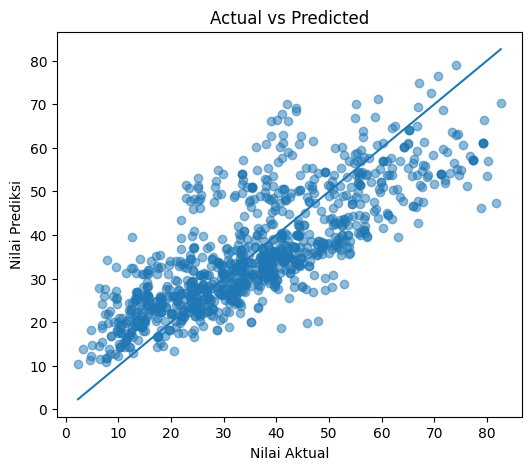

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(Y_matrix, Y_pred, alpha=0.5)

plt.xlabel("Nilai Aktual")
plt.ylabel("Nilai Prediksi")

plt.title("Actual vs Predicted")

plt.plot(
    [Y_matrix.min(), Y_matrix.max()],
    [Y_matrix.min(), Y_matrix.max()]
)

plt.show()

Berdasarkan grafik di atas, sebagian besar titik berada di sekitar garis diagonal. Hal ini menunjukkan bahwa nilai prediksi yang dihasilkan model cukup mendekati nilai aktual sehingga model memiliki kemampuan prediksi yang cukup baik.

## 7. Pengujian Model

### 7.1 Uji Signifikansi Simultan (Uji F)

Uji F digunakan untuk menguji apakah seluruh variabel independen secara bersama-sama berpengaruh signifikan terhadap variabel dependen.

**Hipotesis:**
- H₀: β₁ = β₂ = ... = β₈ = 0 (model tidak signifikan)
- H₁: minimal terdapat satu βᵢ ≠ 0 (model signifikan)

**Statistik Uji F:**

$$
F = \frac{SSR/k}{SSE/(n-k-1)}
$$

dengan:
- \(k\) = jumlah variabel independen
- \(n\) = jumlah observasi

Nilai \(F_{hitung}\) kemudian dibandingkan dengan \(F_{tabel}\) pada tingkat signifikansi \(\alpha = 0.05\).

In [ ]:
n = len(Y_matrix)
k = len(fitur_X)

F_hitung = (SSR / k) / (SSE / (n - k - 1))

print("F_hitung =", F_hitung)

F_hitung = 204.31663730867447


In [ ]:
print(f"F Hitung = {F_hitung:.4f}")
print(f"F Tabel  = {F_tabel:.4f}")

if F_hitung > F_tabel:
    print("Keputusan: Tolak H0")
    print("Kesimpulan: Model regresi signifikan secara simultan.")
else:
    print("Keputusan: Gagal Tolak H0")
    print("Kesimpulan: Model regresi tidak signifikan secara simultan.")

F Hitung = 204.3166
F Tabel  = 1.9400
Keputusan: Tolak H0
Kesimpulan: Model regresi signifikan secara simultan.


### Interpretasi Uji F

Berdasarkan hasil perhitungan diperoleh nilai F_hitung sebesar 204,27.

Dengan tingkat signifikansi α = 0,05, nilai F_hitung jauh lebih besar daripada F_tabel, sehingga H₀ ditolak.

Hal ini menunjukkan bahwa variabel Cement, Blast Furnace Slag, Fly Ash, Water, Superplasticizer, Coarse Aggregate, Fine Aggregate, dan Age secara simultan berpengaruh signifikan terhadap Concrete Compressive Strength.

### 7.2 Uji Signifikansi Parsial (Uji t)

Uji t digunakan untuk menguji apakah setiap koefisien regresi $\beta_i$ secara **individual** berpengaruh signifikan terhadap Y.

**Hipotesis (untuk setiap $\beta_i$):**
- $H_0$: $\beta_i = 0$ (variabel ke-i tidak berpengaruh signifikan)
- $H_1$: $\beta_i \neq 0$ (variabel ke-i berpengaruh signifikan)

**Statistik Uji t:**

$$
t_i = \frac{\hat{\beta}_i}{SE(\hat{\beta}_i)}
$$

dengan standard error koefisien diperoleh dari matriks varians-kovarians:

$$
\text{Var}(\hat{\beta}) = MSE \cdot (X^T X)^{-1}, \qquad SE(\hat{\beta}_i) = \sqrt{\text{Var}(\hat{\beta}_i)}
$$

Nilai $t_{hitung}$ dibandingkan dengan $t_{tabel}$ pada $\alpha = 0.05$ (dua arah) dan $df = n-k-1$. Untuk df yang besar (>120), $t_{tabel} \approx 1.96$.

In [ ]:
# Mean Square Error
MSE = SSE / (n - k - 1)

# Varians-Kovarians Koefisien
var_beta = MSE * np.linalg.inv(X_matrix.T @ X_matrix)

# Standard Error
SE_beta = np.sqrt(np.diag(var_beta))

# t hitung
t_hitung = beta.flatten() / SE_beta

print("Nilai t_hitung:\n")
for nama, t in zip(nama_koef, t_hitung):
    print(f"{nama:25s} : {t:.4f}")

Nilai t_hitung:

Intercept (b0)            : -0.8713
Cement                    : 14.1106
Blast_Furnace_Slag        : 10.2456
Fly_Ash                   : 6.9889
Water                     : -3.7409
Superplasticizer          : 3.1115
Coarse_Aggregate          : 1.9197
Fine_Aggregate            : 1.8833
Age                       : 21.0471


In [ ]:
hasil_uji_t = pd.DataFrame({
    "Variabel": nama_koef,
    "Koefisien": beta.flatten(),
    "Standard Error": SE_beta,
    "t_hitung": t_hitung,
    "Signifikan": [
        "Ya" if abs(t) > 1.96 else "Tidak"
        for t in t_hitung
    ]
})

hasil_uji_t

,Variabel,Koefisien,Standard Error,t_hitung,Signifikan
0,Intercept (b0),-23.163756,26.585508,-0.871293,Tidak
1,Cement,0.119785,0.008489,14.110614,Ya
2,Blast_Furnace_Slag,0.103847,0.010136,10.245586,Ya
3,Fly_Ash,0.087943,0.012583,6.988863,Ya
4,Water,-0.150298,0.040177,-3.740890,Ya
5,Superplasticizer,0.290687,0.093424,3.111477,Ya
6,Coarse_Aggregate,0.018030,0.009392,1.919690,Tidak
7,Fine_Aggregate,0.020154,0.010702,1.883297,Tidak
8,Age,0.114226,0.005427,21.047078,Ya


### Interpretasi Uji t

Berdasarkan hasil uji t dengan nilai kritis t_tabel = 1,96 pada tingkat signifikansi 5%, diperoleh bahwa sebagian besar variabel independen memiliki pengaruh yang signifikan terhadap Concrete Compressive Strength.

Variabel Cement (t = 14,1106), Blast Furnace Slag (t = 10,2456), Fly Ash (t = 6,9889), Water (t = -3,7409), Superplasticizer (t = 3,1115), dan Age (t = 21,0471) memiliki nilai |t_hitung| yang lebih besar dari 1,96 sehingga dinyatakan berpengaruh signifikan terhadap kuat tekan beton.

Sebaliknya, variabel Coarse Aggregate (t = 1,9197) dan Fine Aggregate (t = 1,8833) memiliki nilai |t_hitung| yang lebih kecil dari 1,96 sehingga tidak menunjukkan pengaruh yang signifikan secara statistik pada tingkat signifikansi 5%.

Variabel Age memiliki nilai t_hitung terbesar, yaitu 21,0471, diikuti oleh Cement sebesar 14,1106 dan Blast Furnace Slag sebesar 10,2456. Hal ini menunjukkan bahwa ketiga variabel tersebut memberikan kontribusi yang paling kuat terhadap variasi nilai Concrete Compressive Strength dalam model regresi yang dibangun.

## 8. Prediksi Nilai Y Berdasarkan Nilai X Tertentu

Sebagai contoh penerapan model, dilakukan prediksi kuat tekan beton menggunakan model regresi yang telah diperoleh. Nilai variabel independen yang digunakan merupakan nilai rata-rata masing-masing variabel pada dataset sehingga dapat merepresentasikan kondisi campuran beton secara umum.

In [ ]:
# Data baru yang akan diprediksi
data_baru = np.array([
    1,          # Intercept
    281.17,     # Cement
    73.90,      # Blast Furnace Slag
    54.19,      # Fly Ash
    181.57,     # Water
    6.20,       # Superplasticizer
    972.92,     # Coarse Aggregate
    773.58,     # Fine Aggregate
    45.66       # Age
]).reshape(1, -1)

prediksi = data_baru @ beta

print("Prediksi Concrete Compressive Strength:")
print(prediksi)

Prediksi Concrete Compressive Strength:
[[35.81743205]]


### Interpretasi Hasil Prediksi

Berdasarkan model regresi yang telah dibangun, diperoleh prediksi nilai Concrete Compressive Strength sebesar **35,82 MPa**.

Nilai prediksi tersebut sangat dekat dengan nilai rata-rata aktual Concrete Compressive Strength pada dataset, yaitu sekitar 35,82 MPa. Hal ini menunjukkan bahwa model mampu menghasilkan estimasi yang konsisten terhadap karakteristik data yang digunakan dalam penelitian.

Hasil prediksi ini menunjukkan bagaimana model regresi dapat digunakan untuk memperkirakan kuat tekan beton berdasarkan kombinasi nilai variabel independen yang diberikan.

## 9. Kesimpulan

Berdasarkan hasil analisis korelasi Pearson dan regresi linier berganda pada dataset Concrete Compressive Strength, diperoleh kesimpulan sebagai berikut:

1. Berdasarkan analisis korelasi Pearson, variabel **Cement** memiliki hubungan positif terbesar terhadap **Concrete Compressive Strength** (r = 0,4978), sedangkan variabel **Water** memiliki hubungan negatif terbesar (r = -0,2896). Hasil ini menunjukkan bahwa peningkatan jumlah semen cenderung meningkatkan kuat tekan beton, sedangkan peningkatan jumlah air cenderung menurunkan kuat tekan beton.

2. Model regresi linier berganda yang dibangun menghasilkan nilai **R² = 0,6155**, yang menunjukkan bahwa sekitar **61,55% variasi nilai Concrete Compressive Strength** dapat dijelaskan oleh variabel Cement, Blast Furnace Slag, Fly Ash, Water, Superplasticizer, Coarse Aggregate, Fine Aggregate, dan Age. Sisanya sebesar **38,45%** dipengaruhi oleh faktor lain di luar model.

3. Hasil **Uji F** menghasilkan nilai **F_hitung = 204,27** yang lebih besar daripada **F_tabel = 1,94**, sehingga H₀ ditolak. Dengan demikian, seluruh variabel independen secara simultan berpengaruh signifikan terhadap Concrete Compressive Strength.

4. Hasil **Uji t** menunjukkan bahwa variabel **Cement, Blast Furnace Slag, Fly Ash, Water, Superplasticizer, dan Age** berpengaruh signifikan secara parsial terhadap Concrete Compressive Strength. Sementara itu, variabel **Coarse Aggregate** dan **Fine Aggregate** tidak menunjukkan pengaruh yang signifikan pada tingkat signifikansi 5%.

5. Model regresi yang diperoleh dapat digunakan untuk memprediksi nilai **Concrete Compressive Strength** berdasarkan kombinasi nilai variabel independen tertentu, sebagaimana ditunjukkan pada contoh prediksi yang menghasilkan nilai sebesar **35,82 MPa**.

6. Hasil penelitian menunjukkan bahwa faktor-faktor yang paling berpengaruh terhadap kuat tekan beton dalam model ini adalah **Age**, **Cement**, dan **Blast Furnace Slag**, yang ditunjukkan oleh nilai statistik t yang relatif tinggi dibandingkan variabel lainnya.

Maresti, F. A., Anugraheni, G. M., Hargiyanto, R. A., & Mustaqim, K. (2024). Penerapan exploratory data analysis (EDA) dan analisis recency, frequency, and monetary (RFM) untuk segmentasi pelanggan e-commerce. Competitive, 19(1), 14–25. http://ejurnal.ulbi.ac.id/index.php/competitive